In [2]:
# import necessary packages
import cmapPy.pandasGEXpress.GCToo as GCToo
from cmapPy.pandasGEXpress.parse import parse
import cmapPy.pandasGEXpress.subset_gctoo as sg

import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_curve, roc_auc_score

# Goal
The purpose of this project is to determine drugs treating the same indication (similar drugs) have similar effects on gene signature. The gene signatures were taken from the LINCS L1000 dataset, which is part of the [NIH LINCS L1000 project](https://lincsproject.org/LINCS/tools/workflows/find-the-best-place-to-obtain-the-lincs-l1000-data). This dataset contains gene expression profiles for thousands of perturbagens at a variety of time points, doses, and cell lines. What is unique about this dataset is that they directly measure the gene expression of 978 landmark genes and use a computational model to estimate the gene expression levels of over 10,000 other genes.

## Select only the 978 landmark genes and all the samples that had a high transcriptional response to drug compounds

#### *1. Select the 978 landmark gene ids to extract from .gctx file*

In [3]:
# read gene info from gene_info metadata
file_path = "/home/katie_huang_student_uml_edu/LINCS_dataset/GSE70138_Broad_LINCS_gene_info_2017-03-06.txt"
gene_info = pd.read_csv(file_path, sep="\t", dtype=str)
gene_info.head()

,pr_gene_id,pr_gene_symbol,pr_gene_title,pr_is_lm,pr_is_bing
0,780,DDR1,discoidin domain receptor tyrosine kinase 1,1,1
1,7849,PAX8,paired box 8,1,1
2,2978,GUCA1A,guanylate cyclase activator 1A,0,0
3,2049,EPHB3,EPH receptor B3,0,1
4,2101,ESRRA,estrogen related receptor alpha,0,1


In [4]:
# select the ids of only the landmark genes
lm_gene_id = gene_info["pr_gene_id"][gene_info["pr_is_lm"] == "1"]

# check that I have the 978 landmark genes
print(len(lm_gene_id)) 

978


#### *2. Filter out only the trt_cp data using GSE70138_Broad_LINCS_sig_info.txt and save into trt_cps_sig_info.txt with the command line:*
``` bash
grep trt_cp GSE70138_Broad_LINCS_sig_info.txt | cut -f-3,5-8 > trt_cps.txt
head -1 GSE70138_Broad_LINCS_sig_info.txt | cut -f-3,5-8 > column_names_sig_info.txt
cat column_names_sig_info.txt trt_cps.txt > trt_cps_sig_info.txt
rm column_names_sig_info.txt trt_cps.txt
```

## Map the drugs to the diseases

The diseases related to each drug was taken from the Broad Institute:
https://repo-hub.broadinstitute.org/repurposing#download-data

In [5]:
# import the disease information for each drug
file_path = '/home/katie_huang_student_uml_edu/LINCS_dataset/repurposing_drugs_20200324.txt'
disease_info = pd.read_csv(file_path, sep="\t", dtype=str, skiprows=9)

# set the index as the name of the compound
disease_info.set_index('pert_iname', inplace=True)
disease_info.head()

,clinical_phase,moa,target,disease_area,indication
pert_iname,,,,,
(R)-(-)-apomorphine,Launched,dopamine receptor agonist,ADRA2A|ADRA2B|ADRA2C|CALY|DRD1|DRD2|DRD3|DRD4|...,neurology/psychiatry,Parkinson's Disease
(R)-(-)-rolipram,Phase 1,phosphodiesterase inhibitor,PDE4A|PDE4B|PDE4C|PDE4D|PDE5A,NaN,NaN
(R)-baclofen,Phase 3,benzodiazepine receptor agonist,GABBR1|GABBR2,NaN,NaN
(S)-(+)-rolipram,Phase 1,phosphodiesterase inhibitor,PDE4B|PDE4D,NaN,NaN
"[sar9,met(o2)11]-substance-p",Preclinical,tachykinin antagonist,TACR1,NaN,NaN


In [6]:
# remove pert_inames where there is no indication (NaN)
disease_info = disease_info[disease_info['indication'].notna()]
disease_info.head(10)

,clinical_phase,moa,target,disease_area,indication
pert_iname,,,,,
(R)-(-)-apomorphine,Launched,dopamine receptor agonist,ADRA2A|ADRA2B|ADRA2C|CALY|DRD1|DRD2|DRD3|DRD4|...,neurology/psychiatry,Parkinson's Disease
abacavir,Launched,nucleoside reverse transcriptase inhibitor,NaN,infectious disease,human immunodeficiency virus (HIV-1)
abamectin,Launched,benzodiazepine receptor agonist,GABBR1|GABBR2,infectious disease,gastrointestinal parasites
abemaciclib,Launched,CDK inhibitor,CDK4|CDK6,oncology,breast cancer
abiraterone,Launched,androgen biosynthesis inhibitor,CYP11B1|CYP17A1,oncology,prostate cancer
abiraterone-acetate,Launched,androgen biosynthesis inhibitor,CYP17A1,oncology,prostate cancer
acalabrutinib,Launched,Bruton's tyrosine kinase (BTK) inhibitor,BTK,hematologic malignancy,mantle cell lymphoma (MCL)
acamprosate,Launched,glutamate receptor antagonist,GABRA1|GABRA2|GABRA3|GABRA4|GABRA5|GABRA6|GABR...,neurology/psychiatry,abstinence from alcohol
acarbose,Launched,glucosidase inhibitor,AMY2A|MGAM,endocrinology,diabetes mellitus


In [7]:
# obtain the pert_info data
file_path = '/home/katie_huang_student_uml_edu/LINCS_dataset/GSE70138_Broad_LINCS_pert_info.txt'
pert_info = pd.read_csv(file_path, sep="\t", dtype=str)

# set the index of the dataframe as the pert_iname
pert_info.set_index('pert_iname', inplace=True)
pert_info.head(10)

,pert_id,canonical_smiles,inchi_key,pert_type
pert_iname,,,,
10-DEBC,BRD-K70792160,CCN(CC)CCCCN1c2ccccc2Oc2ccc(Cl)cc12,GYBXAGDWMCJZJK-UHFFFAOYSA-N,trt_cp
phorbol-myristate-acetate,BRD-K68552125,CCCCCCCCCCCCCC(=O)O[C@@H]1[C@@H](C)[C@]2(O)[C@...,PHEDXBVPIONUQT-RGYGYFBISA-N,trt_cp
"16,16-dimethylprostaglandin-e2",BRD-K92301463,CCCCC(C)(C)[C@H](O)\C=C\[C@H]1[C@H](O)CC(=O)[C...,QAOBBBBDJSWHMU-WMBBNPMCSA-N,trt_cp
17-hydroxyprogesterone-caproate,BRD-A29731977,CCCCCC(=O)O[C@@]1(CCC2C3CCC4=CC(=O)CC[C@]4(C)C...,DOMWKUIIPQCAJU-JKPPDDDBSA-N,trt_cp
2-iminobiotin,BRD-K07954936,OC(=O)CCCC[C@@H]1SC[C@@H]2NC(=N)N[C@H]12,WWVANQJRLPIHNS-ZKWXMUAHSA-N,trt_cp
2-methoxyestradiol,BRD-K44408410,COc1cc2[C@H]3CC[C@]4(C)[C@@H](O)CC[C@H]4[C@@H]...,CQOQDQWUFQDJMK-SSTWWWIQSA-N,trt_cp
"2',5'-dideoxyadenosine",BRD-A20131130,CC1OC(CC1O)n1cnc2c(N)ncnc12,FFHPXOJTVQDVMO-UHFFFAOYSA-N,trt_cp
3-amino-benzamide,BRD-K08703257,NC(=O)c1cccc(N)c1,GSCPDZHWVNUUFI-UHFFFAOYSA-N,trt_cp
3-deazaadenosine,BRD-A79431551,Nc1nccc2n(cnc12)[C@@H]1O[C@H](CO)C(O)C1O,DBZQFUNLCALWDY-JXACCQRMSA-N,trt_cp


In [8]:
# select only the drugs associated with a disease
drug_to_disease = pert_info.merge(disease_info, how='inner', on='pert_iname')
drug_to_disease.head()

,pert_id,canonical_smiles,inchi_key,pert_type,clinical_phase,moa,target,disease_area,indication
pert_iname,,,,,,,,,
17-hydroxyprogesterone-caproate,BRD-A29731977,CCCCCC(=O)O[C@@]1(CCC2C3CCC4=CC(=O)CC[C@]4(C)C...,DOMWKUIIPQCAJU-JKPPDDDBSA-N,trt_cp,Launched,progesterone receptor agonist,AR|ESR1|ESR2|NR1H4|NR1I2|NR3C1|PGR,obstetrics/gynecology,spontaneous preterm birth
5-aminolevulinic-acid,BRD-K57631554,NCC(=O)CCC(O)=O,ZGXJTSGNIOSYLO-UHFFFAOYSA-N,trt_cp,Launched,oxidizing agent,ALAD,oncology|dermatology,glioma|actinic keratosis (AK)
abacavir,BRD-A95032015,Nc1nc(NC2CC2)c2ncn(C3C[C@H](CO)C=C3)c2n1,MCGSCOLBFJQGHM-HNHGDDPOSA-N,trt_cp,Launched,nucleoside reverse transcriptase inhibitor,NaN,infectious disease,human immunodeficiency virus (HIV-1)
abiraterone-acetate,BRD-K16133773,CC(=O)O[C@H]1CC[C@]2(C)[C@@H]3CC[C@@]4(C)[C@@H...,UVIQSJCZCSLXRZ-HCWFNAMGSA-N,trt_cp,Launched,androgen biosynthesis inhibitor,CYP17A1,oncology,prostate cancer
acarbose,BRD-K01621533,C[C@@H]1O[C@H](O[C@@H]2[C@H](CO)O[C@H](O[C@@H]...,XUFXOAAUWZOOIT-PCKYEMPFSA-N,trt_cp,Launched,glucosidase inhibitor,AMY2A|MGAM,endocrinology,diabetes mellitus


In [9]:
# calculate the total number of drugs associated with a disease
len(drug_to_disease)

884

In [10]:
# sort the drugs by their disease area and disease indication
drug_to_disease = drug_to_disease.sort_values(by=['disease_area', 'indication'])
drug_to_disease.head()

,pert_id,canonical_smiles,inchi_key,pert_type,clinical_phase,moa,target,disease_area,indication
pert_iname,,,,,,,,,
acrivastine,BRD-K50163129,Cc1ccc(cc1)C(=C/CN1CCCC1)\c1cccc(\C=C\C(O)=O)n1,PWACSDKDOHSSQD-IUTFFREVSA-N,trt_cp,Launched,histamine receptor antagonist,HRH1,allergy,allergic rhinitis
beclomethasone-dipropionate,BRD-A11319535,CCC(=O)OCC(=O)C1(OC(=O)CC)C(C)CC2C3CCC4=CC(=O)...,KUVIULQEHSCUHY-UHFFFAOYSA-N,trt_cp,Launched,glucocorticoid receptor agonist,GPR97|NR3C1,allergy,allergic rhinitis
ciclesonide,BRD-K35245662,CC(C)C(=O)OCC(=O)[C@@]12O[C@@H](O[C@@H]1C[C@H]...,LUKZNWIVRBCLON-GXOBDPJESA-N,trt_cp,Launched,glucocorticoid receptor agonist,NR3C1|SERPINA6,allergy,allergic rhinitis
clemizole,BRD-K04704168,Clc1ccc(Cn2c(CN3CCCC3)nc3ccccc23)cc1,CJXAEXPPLWQRFR-UHFFFAOYSA-N,trt_cp,Launched,HCV inhibitor,NaN,allergy,allergic rhinitis
diphenylpyraline,BRD-K22936972,CN1CCC(CC1)OC(c1ccccc1)c1ccccc1,OWQUZNMMYNAXSL-UHFFFAOYSA-N,trt_cp,Launched,dopamine reuptake inhibitor,HRH1|SLC6A3,allergy,allergic rhinitis


## Select the gene signatures ids of compounds of interest

#### *1. Select gene signature info and TAS scores of samples treated for one cell line*

In [11]:
## select the gene sig
def select_samples (cell_line, tas_threshold):
    ### 1. select the gene signatures of samples that were treated with cell line of interest
    # read the gene signature info
    file_path = "/home/katie_huang_student_uml_edu/LINCS_dataset/trt_cps_sig_info.txt"
    sig_info = pd.read_csv(file_path, sep="\t", dtype=str)
    sig_info.set_index("sig_id", inplace=True)
    ###
    
    # select only the gene signature ids for cell line
    cell_line_sig_info = sig_info[sig_info['cell_id'] == cell_line]
    
    ### 2. Of the samples treated with one cell line, select those that were above TAS threshold
    # read the TAS scores of the gene signatures
    file_path = "LINCS_dataset/all_data/GSE70138_Broad_LINCS_sig_metrics_2017-03-06.txt"
    tas_trt_cps = pd.read_csv(file_path, sep="\t", index_col=0)
    tas_trt_cps.set_index('sig_id', inplace=True)

    # get the tas scores of samples treated with cell line
    cell_line_tas = tas_trt_cps.loc[cell_line_sig_info.index, 'tas']
    
    # add the TAS scores to the sig_info for cell line
    cell_line_trt_cps = pd.concat([cell_line_sig_info, cell_line_tas], axis=1)
    
    # sort the TAS scores in descending order
    top_trt_cps = cell_line_trt_cps.sort_values(by='tas', ascending=False)
    top_trt_cps['tas'] = top_trt_cps['tas'].astype(float)

    # select only the ones above a TAS threshold
    high_tas_trt_cps = top_trt_cps[top_trt_cps['tas'] > tas_threshold]
    ###
    
    ### 3. For each unique compound, select only the samples with the highest tas score
    # create a list to store the sig ids of all the samples with that highest tas scores
    highest_tas_sig_ids = []

    # group the data by the name of the compound
    by_cps = high_tas_trt_cps.groupby("pert_iname")

    # store the compound names and their sig ids in a dictionary
    cp2samples = by_cps.groups

    # look at each compound names and the sig ids for that compound
    for cp_name, sig_ids in cp2samples.items():
        # obtain the dataframe with that data
        data = high_tas_trt_cps.loc[sig_ids]

        # sort the data by highest tas
        tas_sorted = data.sort_values('tas', ascending=False)

        # obtain the data for the sample with the highest tas scores
        highest_tas = tas_sorted.iloc[0]

        # add the sig id to the running list
        highest_tas_sig_ids.append(highest_tas.name)

    # create a dataframe containing the tas score for each unique compound whose TAS is above threshold
    samples2compare = high_tas_trt_cps.loc[highest_tas_sig_ids]
    ###
    
    return samples2compare

In [12]:
# check that this works for MCF7 cell line
samples2compare = select_samples('MCF7', 0.6)
samples2compare.head(10)

,pert_id,pert_iname,cell_id,pert_idose,pert_itime,distil_id,tas
sig_id,,,,,,,
REP.A022_MCF7_24H:I01,BRD-K71281111,SNX-2112,MCF7,10.0 um,24 h,REP.A022_MCF7_24H_X1_B23:I01|REP.A022_MCF7_24H...,0.722739
REP.A008_MCF7_24H:A09,BRD-A68009927,daunorubicin,MCF7,1.11 um,24 h,REP.A008_MCF7_24H_X1_B24:A09|REP.A008_MCF7_24H...,0.773276
REP.A011_MCF7_24H:J05,BRD-K06335600,tizanidine,MCF7,0.12 um,24 h,REP.A011_MCF7_24H_X1_B24:J05|REP.A011_MCF7_24H...,0.629051
REP.A025_MCF7_24H:P03,BRD-K79131256,albendazole,MCF7,1.11 um,24 h,REP.A025_MCF7_24H_X1_B23:P03|REP.A025_MCF7_24H...,0.654995
LJP006_MCF7_24H:H14,BRD-K43389698,BMS-387032,MCF7,3.33 um,24 h,LJP006_MCF7_24H_X1_B17:H14|LJP006_MCF7_24H_X2_...,0.751182
REP.A021_MCF7_24H:J09,BRD-K83837640,JNJ-26481585,MCF7,1.11 um,24 h,REP.A021_MCF7_24H_X1_B23:J09|REP.A021_MCF7_24H...,0.781182
REP.A018_MCF7_24H:J20,BRD-K64925568,AMG-232,MCF7,3.33 um,24 h,REP.A018_MCF7_24H_X1_B24:J20|REP.A018_MCF7_24H...,0.768454
REP.A015_MCF7_24H:O10,BRD-K61195623,combretastatin-A-4,MCF7,0.37 um,24 h,REP.A015_MCF7_24H_X1_B23:O10|REP.A015_MCF7_24H...,0.654698
LJP008_MCF7_24H:A03,BRD-K81418486,vorinostat,MCF7,10.0 um,24 h,LJP008_MCF7_24H_X1_B20:A03|LJP008_MCF7_24H_X2_...,0.707743


## Map drugs to be compared to their indications

In [14]:
def drug_to_indication(samples2compare):
    # of the samples to compare, select those that have a disease associated with it
    test_samples = samples2compare[samples2compare['pert_iname'].isin(drug_to_disease.index)]

    # obtain the unique compound ids with associated diseases
    unique_cp_ids = test_samples['pert_id'].unique()

    # list the indications of these compounds
    drug2indications = drug_to_disease[['pert_id', 'indication']][drug_to_disease['pert_id'].isin(unique_cp_ids)]
    
    # change row names to pert_ids
    drug2indications = drug2indications.reset_index().set_index('pert_id')
    
    # change the row names to pert_ids
    test_samples = test_samples.reset_index().set_index('pert_id')
    
    # create new dataframe containing all sample info and their indications
    drug2indications = pd.concat([test_samples, drug2indications['indication']], axis=1, sort=True)

    # change the row names to sig_ids
    drug2indications = drug2indications.reset_index().set_index('sig_id')
    
    return drug2indications

In [15]:
# check that function works
drug2indications = drug_to_indication(samples2compare)
drug2indications.head(10)

,index,pert_iname,cell_id,pert_idose,pert_itime,distil_id,tas,indication
sig_id,,,,,,,,
REP.A009_MCF7_24H:N01,BRD-A33084557,tioconazole,MCF7,10.0 um,24 h,REP.A009_MCF7_24H_X1_B24:N01|REP.A009_MCF7_24H...,0.740861,yeast infection
REP.A020_MCF7_24H:L01,BRD-A45889380,mepacrine,MCF7,10.0 um,24 h,REP.A020_MCF7_24H_X1_B23:L01|REP.A020_MCF7_24H...,0.806568,giardiasis
REP.A018_MCF7_24H:N08,BRD-A66419424,ixazomib-citrate,MCF7,3.33 um,24 h,REP.A018_MCF7_24H_X1_B24:N08|REP.A018_MCF7_24H...,0.747696,multiple myeloma
REP.A018_MCF7_24H:P03,BRD-A67097164,ifosfamide,MCF7,1.11 um,24 h,REP.A018_MCF7_24H_X1_B24:P03|REP.A018_MCF7_24H...,0.633877,testicular carcinoma|hemorrhagic cystitis
REP.A008_MCF7_24H:A09,BRD-A68009927,daunorubicin,MCF7,1.11 um,24 h,REP.A008_MCF7_24H_X1_B24:A09|REP.A008_MCF7_24H...,0.773276,acute myeloid leukemia (AML)|acute lymphoblast...
REP.A024_MCF7_24H:E11,BRD-A74914197,pralatrexate,MCF7,0.12 um,24 h,REP.A024_MCF7_24H_X1_B23:E11|REP.A024_MCF7_24H...,0.652038,peripheral T-cell lymphoma (PTCL)
LJP009_MCF7_24H:B03,BRD-A79768653,sirolimus,MCF7,10.0 um,24 h,LJP009_MCF7_24H_X1_B20:B03|LJP009_MCF7_24H_X2_...,0.642838,organ rejection|lymphangioleiomyomatosis
REP.A027_MCF7_24H:E08,BRD-A94756469,digoxin,MCF7,3.33 um,24 h,REP.A027_MCF7_24H_X1_B25:E08|REP.A027_MCF7_24H...,0.740309,congestive heart failure|atrial fibrillation (AF)
REP.A011_MCF7_24H:J05,BRD-K06335600,tizanidine,MCF7,0.12 um,24 h,REP.A011_MCF7_24H_X1_B24:J05|REP.A011_MCF7_24H...,0.629051,spasms


## Select gene signatures

In [16]:
# read the LINCS Level 5 dataset
file_path = "/home/katie_huang_student_uml_edu/LINCS_dataset/LINCS_dataset.gctx"

# select only the landmark gene of drug compounds of interest
gene_sigs = parse(file_path, rid=lm_gene_id, cid=drug2indications.index)

In [17]:
# create a new GCTOO object with all the metadata for pair 
sig_info = GCToo.GCToo(data_df=gene_sigs.data_df.copy(), 
                        row_metadata_df=gene_sigs.row_metadata_df.copy(), 
                        col_metadata_df=drug2indications,
                        make_multiindex=True)
sig_info.multi_index_df[:5]

index,BRD-K21361524,BRD-K21680192,BRD-K43586850,BRD-K52020312,BRD-A68009927,BRD-K35960502,BRD-K89561498,BRD-A33084557,BRD-K13646352,BRD-K14619660,...,BRD-K74717603,BRD-K75649340,BRD-K76674262,BRD-K79131256,BRD-K92093830,BRD-K93779381,BRD-A94756469,BRD-K81418486,BRD-K17743125,BRD-A79768653
pert_iname,selinexor,mitoxantrone,lacidipine,metronidazole,daunorubicin,niclosamide,SN-38,tioconazole,midostaurin,altrenogest,...,etravirine,tioguanine,homoharringtonine,albendazole,doxorubicin,ingenol-mebutate,digoxin,vorinostat,belinostat,sirolimus
cell_id,MCF7,MCF7,MCF7,MCF7,MCF7,MCF7,MCF7,MCF7,MCF7,MCF7,...,MCF7,MCF7,MCF7,MCF7,MCF7,MCF7,MCF7,MCF7,MCF7,MCF7
pert_idose,10.0 um,1.11 um,0.04 um,1.11 um,1.11 um,10.0 um,3.33 um,10.0 um,3.33 um,1.11 um,...,10.0 um,10.0 um,0.37 um,1.11 um,3.33 um,0.12 um,3.33 um,10.0 um,10.0 um,10.0 um
pert_itime,24 h,24 h,24 h,24 h,24 h,24 h,24 h,24 h,24 h,24 h,...,24 h,24 h,24 h,24 h,24 h,24 h,24 h,24 h,24 h,24 h
distil_id,REP.A004_MCF7_24H_X1_B27:E13|REP.A004_MCF7_24H_X2_B27:E13|REP.A004_MCF7_24H_X3_B27:E13,REP.A006_MCF7_24H_X1_B22:I15|REP.A006_MCF7_24H_X2_B24:I15|REP.A006_MCF7_24H_X3_B22:I15,REP.A007_MCF7_24H_X1_B22:B24|REP.A007_MCF7_24H_X2_B22:B24|REP.A007_MCF7_24H_X3.A2_B23:B24,REP.A007_MCF7_24H_X1_B22:G21|REP.A007_MCF7_24H_X2_B22:G21|REP.A007_MCF7_24H_X3.A2_B23:G21,REP.A008_MCF7_24H_X1_B24:A09|REP.A008_MCF7_24H_X2_B24:A09|REP.A008_MCF7_24H_X3_B24:A09,REP.A008_MCF7_24H_X1_B24:A13|REP.A008_MCF7_24H_X2_B24:A13|REP.A008_MCF7_24H_X3_B24:A13,REP.A008_MCF7_24H_X1_B24:O14|REP.A008_MCF7_24H_X2_B24:O14|REP.A008_MCF7_24H_X3_B24:O14,REP.A009_MCF7_24H_X1_B24:N01|REP.A009_MCF7_24H_X2_B24:N01|REP.A009_MCF7_24H_X3_B24:N01,REP.A010_MCF7_24H_X1_B24:I02|REP.A010_MCF7_24H_X2_B24:I02|REP.A010_MCF7_24H_X3_B24:I02,REP.A010_MCF7_24H_X1_B24:L03|REP.A010_MCF7_24H_X2_B24:L03|REP.A010_MCF7_24H_X3_B24:L03,...,REP.A025_MCF7_24H_X1_B23:I07|REP.A025_MCF7_24H_X2_B23:I07|REP.A025_MCF7_24H_X3_B23:I07,REP.A025_MCF7_24H_X1_B23:J19|REP.A025_MCF7_24H_X2_B23:J19|REP.A025_MCF7_24H_X3_B23:J19,REP.A025_MCF7_24H_X1_B23:L10|REP.A025_MCF7_24H_X2_B23:L10|REP.A025_MCF7_24H_X3_B23:L10,REP.A025_MCF7_24H_X1_B23:P03|REP.A025_MCF7_24H_X2_B23:P03,REP.A026_MCF7_24H_X1_B25:L20|REP.A026_MCF7_24H_X2_B25:L20|REP.A026_MCF7_24H_X3_B25:L20,REP.A027_MCF7_24H_X1_B25:D23|REP.A027_MCF7_24H_X2_B25:D23|REP.A027_MCF7_24H_X3_B25:D23,REP.A027_MCF7_24H_X1_B25:E08|REP.A027_MCF7_24H_X2_B25:E08|REP.A027_MCF7_24H_X3_B25:E08,LJP008_MCF7_24H_X1_B20:A03|LJP008_MCF7_24H_X2_B20:A03|LJP008_MCF7_24H_X3_B20:A03,LJP008_MCF7_24H_X1_B20:L19|LJP008_MCF7_24H_X2_B20:L19|LJP008_MCF7_24H_X3_B20:L19,LJP009_MCF7_24H_X1_B20:B03|LJP009_MCF7_24H_X2_B20:B03|LJP009_MCF7_24H_X3_B20:B03
tas,0.697827,0.681046,0.666125,0.641509,0.773276,0.720621,0.787751,0.740861,0.799386,0.812819,...,0.642719,0.658646,0.799271,0.654995,0.732233,0.624958,0.740309,0.707743,0.672252,0.642838
indication,multiple myeloma,multiple sclerosis|prostate cancer|acute myeloid leukemia (AML),hypertension,rosacea,acute myeloid leukemia (AML)|acute lymphoblastic leukemia (ALL),tapeworm,colorectal cancer,yeast infection,acute myeloid leukemia (AML),estrus,...,human immunodeficiency virus (HIV-1),acute myeloid leukemia (AML)|acute lymphoblastic leukemia (ALL)|chronic myeloid leukemia (CML),chronic myeloid leukemia (CML),cystic hydatid disease|parenchymal neurocysticercosis,acute lymphoblastic leukemia (ALL)|acute myeloid leukemia (AML)|Wilm's tumor|breast cancer|ovarian cancer|Hodgkin's lymphoma|bladder cancer|multiple myeloma,actinic keratosis (AK),congestive heart failure|atrial fibrillation (AF),cutaneous T-cell lymphoma (CTCL),peripheral T-cell lymphoma (PTCL),organ rejection|lymphangioleiomyomatosis
cid,REP.A004_MCF7_24H:E13,REP.A006_MCF7_24H:I15,REP.A007_MCF7_24H:B24,REP.A007_MCF7_24H:G21,REP.A008_MCF7_24H:A09,REP.A008_MCF7_24H:A13,REP.A008_MCF7_24H:O14,REP.A009_MCF7_24H:N01,REP.A010_MCF7_24H:I02,REP.A010_MCF7_24H:L03,...,REP.A025_MCF7_24H:I07,REP.A025_MCF7_24H:J19,REP.A025_MCF7_24H:L10,REP.A025_MCF7_24H:P03,REP.A026_MCF7_24H:L20,REP

## Perform pairwise spearman correlations

In [18]:
def spearman_corr(sig_info, drug2indications):
    ### 1. perform spearman correlations for all 
    # perform pairwise spearman correlations
    spearman_corrs = sig_info.data_df.corr(method='spearman')

    # set the row and column names to the indications
    cp_names = sig_info.col_metadata_df['pert_iname']
    spearman_corrs.index = cp_names
    spearman_corrs.columns = cp_names
    ###
    
    ### 2. create a new dataframe with all the spearman correlation information
    # initialize an empty to store information for dataframe
    cp_pair = []
    
    # for each drug available
    for idx1, sig_id1 in enumerate(drug2indications.index):
        # get the name of the drug
        cp1_name = drug2indications.loc[sig_id1, 'pert_iname']
        # store the indication of this drug
        cp1_indications = drug2indications.loc[sig_id1,'indication'].split('|')

        # store the data for the remaining drugs
        other_cps = drug2indications.index[idx1+1:]

        # go through each of the other drugs
        for sig_id2 in other_cps:
            # store the name of the other drug
            cp2_name = drug2indications.loc[sig_id2,'pert_iname']
            # store the indications for this drug
            cp2_indications = drug2indications.loc[sig_id2,'indication'].split('|')
            # store whether they share an indication
            share_indication = any(item in cp2_indications for item in cp1_indications)
            # store the spearman correlation
            corr = spearman_corrs.loc[cp1_name, cp2_name]
            # get the shared indications
            indications_set = set(cp1_indications) & set(cp2_indications)
            # joing together as one string
            indications_str = ', '.join(map(str, indications_set))
            
            # create a dictionary to store the information that will be added to the new dataframe
            row_info = {
                'drug1': cp1_name,
                'drug2': cp2_name,
                'share indication': share_indication,
                'indication': indications_str,
                'spearman correlation': corr,
            }

            # add the dictionary as a row to the list
            cp_pair.append(row_info)

    # convert list into a dataframe
    cp_pair = pd.DataFrame(cp_pair)
    ### 
    
    return cp_pair

In [19]:
# perform spearman correlations
spearman_corrs = spearman_corr(sig_info, drug2indications)
spearman_corrs[spearman_corrs['share indication']]

,drug1,drug2,indication,share indication,spearman correlation
91,ixazomib-citrate,carfilzomib,multiple myeloma,True,0.839315
94,ixazomib-citrate,selinexor,multiple myeloma,True,0.327204
100,ixazomib-citrate,bortezomib,multiple myeloma,True,0.753561
116,ixazomib-citrate,ixazomib,multiple myeloma,True,0.889649
120,ixazomib-citrate,doxorubicin,multiple myeloma,True,0.222742
166,daunorubicin,midostaurin,acute myeloid leukemia (AML),True,0.344347
172,daunorubicin,mitoxantrone,acute myeloid leukemia (AML),True,0.597887
176,daunorubicin,thioguanine,acute myeloid leukemia (AML),True,0.344000
184,daunorubicin,amsacrine,acute lymphoblastic leukemia (ALL),True,0.389688
188,daunorubicin,tioguanine,"acute lymphoblastic leukemia (ALL), acute myel...",True,0.351537


In [20]:
# compare to spearman correlations

## Summarize spearman correlations

#### *1. Summarize these spearman correlations with a violin plot*

In [21]:
def summarize_corrs(cell_line, tas_threshold, spearman_corrs):
    # create a new figure for the histograms with specified sizes
    plt.figure(figsize=(10,10))

    # set a grid on the histograms
    sns.set(style='whitegrid')

    # create a histogram of all spearman correlations for pairs of similar drugs
    sns.violinplot(data=spearman_corrs, x='share indication', y='spearman correlation', inner='box', common_norm=False)

    # title
    plt.title('cell line: ' + cell_line + '; TAS > ' + str(tas_threshold))

    # axis labels
    plt.xticks([0, 1], ['do not share an indication', 'share an indication'])
    plt.ylabel("Spearman correlations")

    # show the plot
    plt.show()

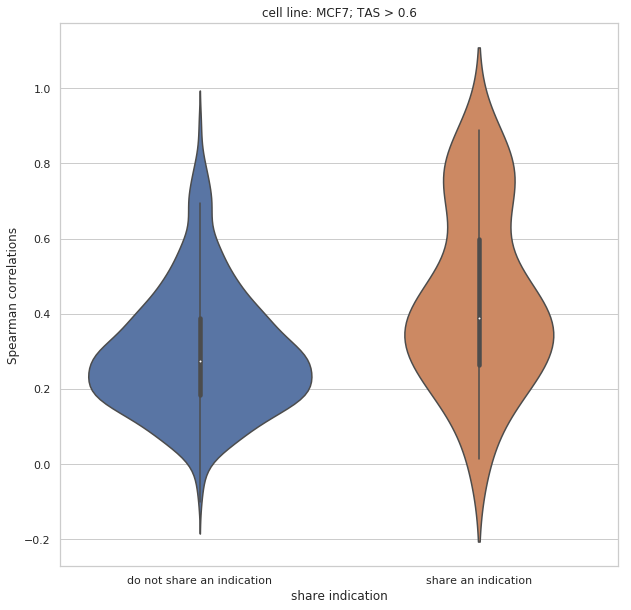

In [22]:
# run for example
summarize_corrs('MCF7', 0.6, spearman_corrs)

#### *2. Obtain the AUROC scores at each TAS threshold*

In [23]:
def roc_score(is_similar, corrs, tas_threshold, total_cps):
    # calculate AUROC score
    auc = roc_auc_score(is_similar, corrs)

    # store the false positive rate and total positive rate for the ROC curve
    fpr, tpr, _ = roc_curve(is_similar, corrs)
    
    # plot the ROC curve
    plt.plot(fpr, tpr, label='TAS = %.2f (AUROC = %.3f), %d cps' % (tas_threshold, auc, total_cps))

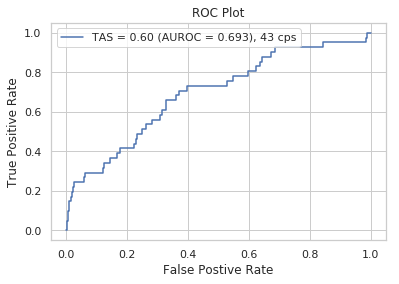

In [24]:
# create ROC curve with one TAS threshold
roc_score(spearman_corrs['share indication'], spearman_corrs['spearman correlation'], 0.6, len(drug2indications))

# title
plt.title('ROC Plot')

# axes labels
plt.xlabel('False Postive Rate')
plt.ylabel('True Positive Rate')

# legend
plt.legend()

# show plot
plt.show()

In [44]:
# method to obtain one ROC plot with ROC curves for all TAS thresholds
def roc_scores(cell_line, spearman_corrs, tas_thresholds, total_cps):
    # initialize a figure size
    plt.figure(figsize=(10,10))
    
    # for each tas threshold,
    for tas in tas_thresholds:
        # store the data for that tas
        tas_data = spearman_corrs[tas]
        # store the binary classification whether pair of drugs are similar/different
        is_similar = tas_data['share indication']
        # store the spearman correlations
        corrs = tas_data['spearman correlation']
        # perform a ROC curve the spearman correlations for each TAS threshold
        roc_score(is_similar, corrs, tas, total_cps[tas])

    # title
    plt.title(cell_line + ' ROC Plot')

    # axes labels
    plt.xlabel('False Postive Rate')
    plt.ylabel('True Positive Rate')

    # legend
    plt.legend(loc='lower right')

    # show plot
    plt.show()

## Run analysis for a range of TAS thresholds

#### *a. MCF7 cell line*

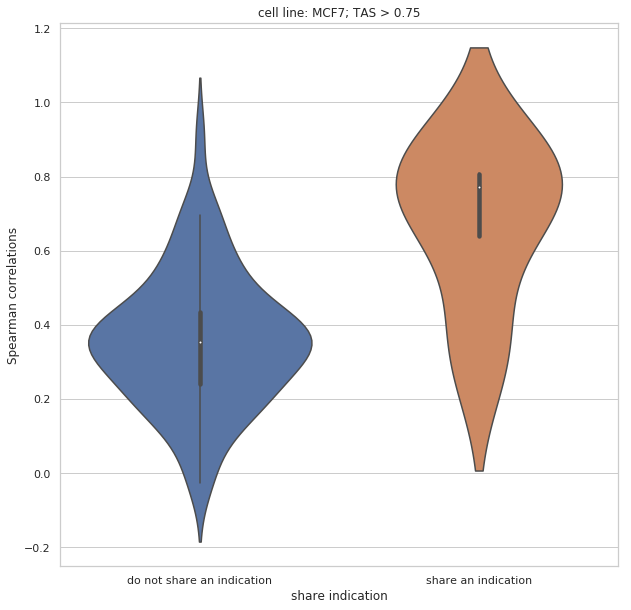

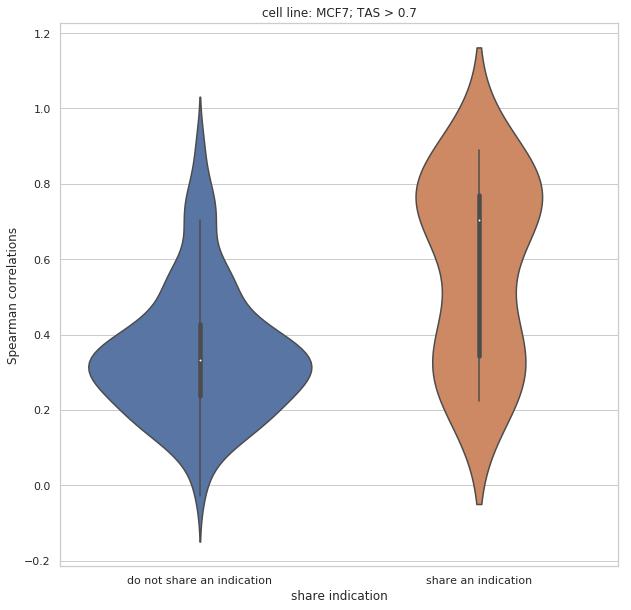

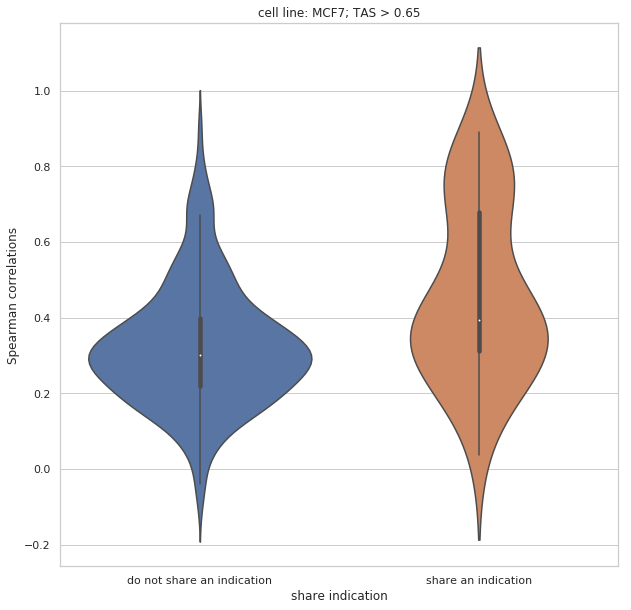

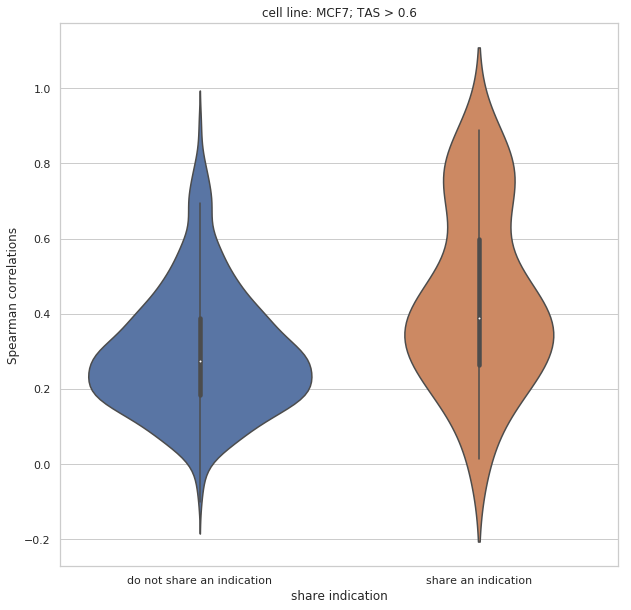

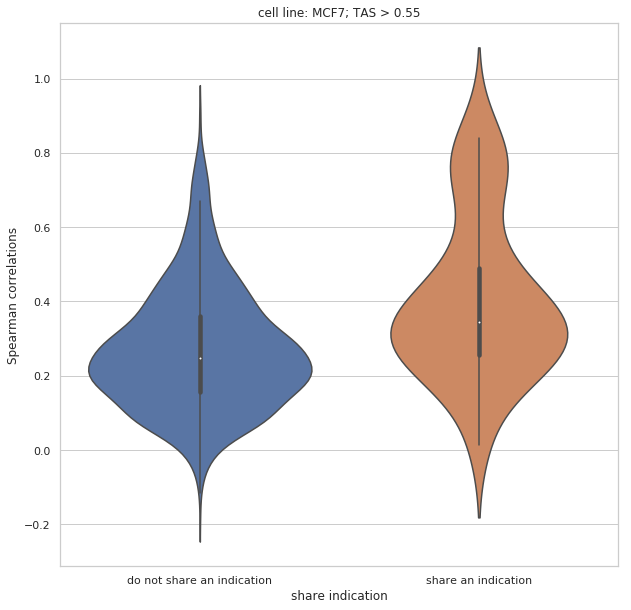

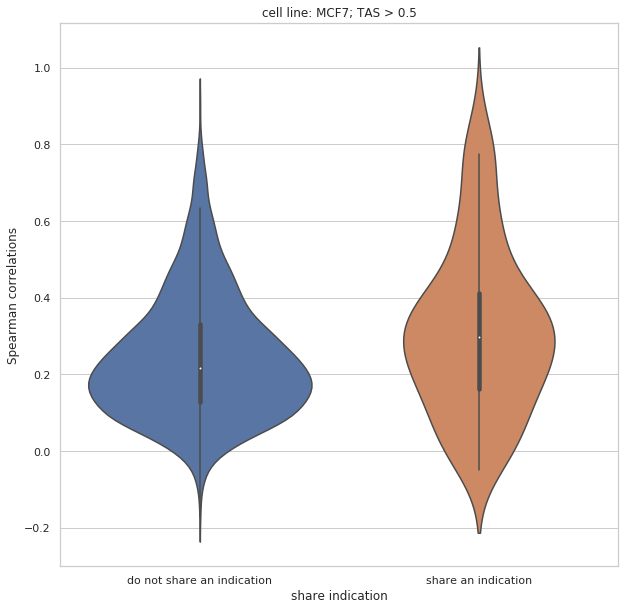

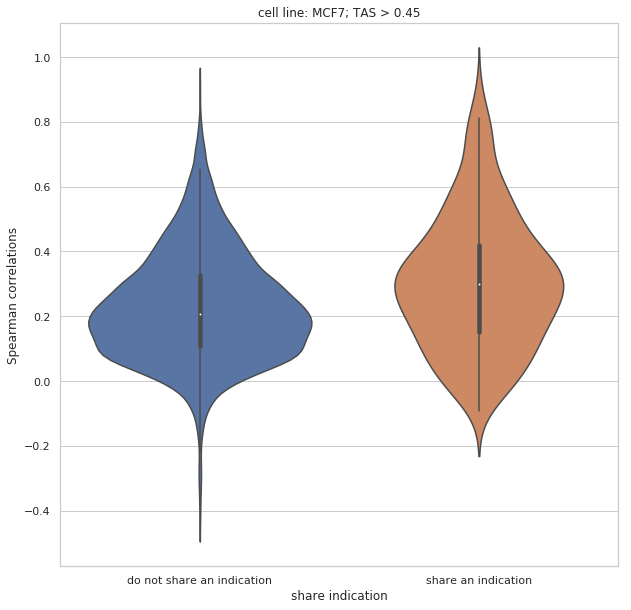

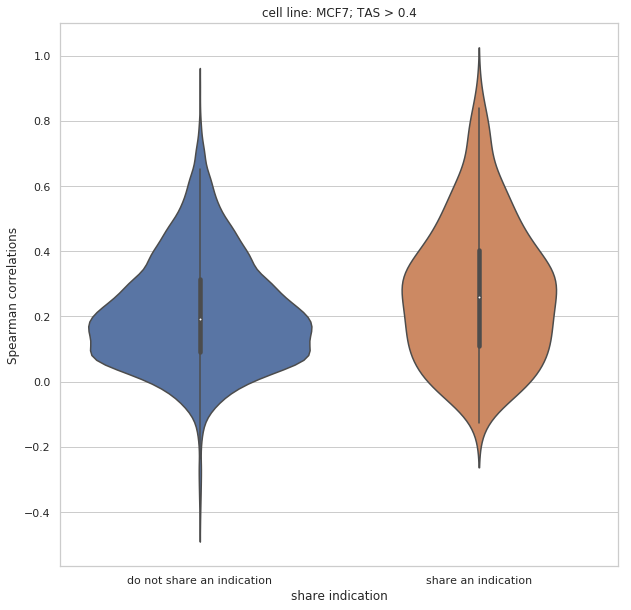

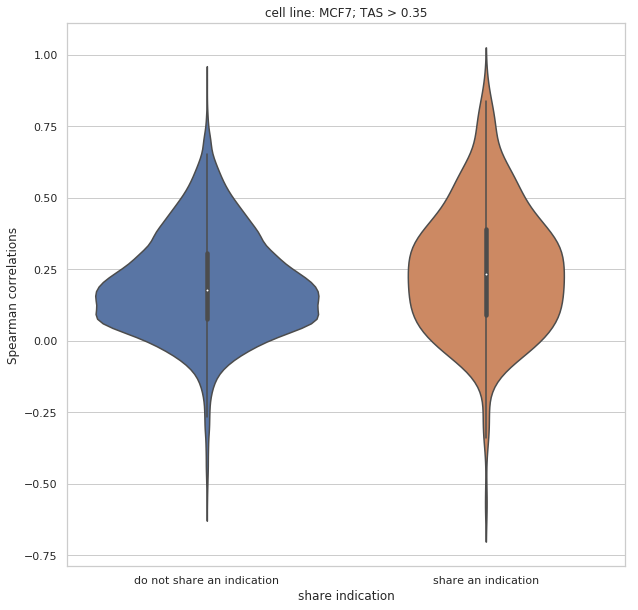

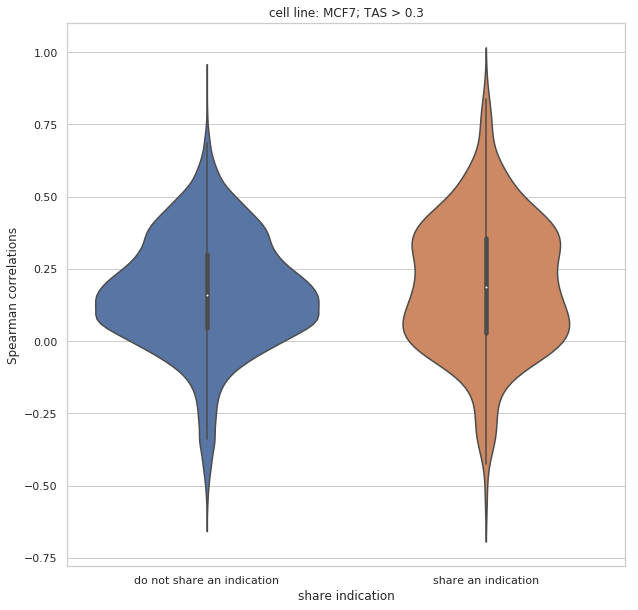

In [25]:
# create an empty dictionary to store the spearman_correlations for each the tas_threshold
MCF7_spearman_corrs = {}

# create a list of all TAS thresholds you want to be compared
tas_thresholds = [0.75, 0.7, 0.65, 0.6, 0.55, 0.5, 0.45, 0.4, 0.35, 0.3]

# create an empty list to store the total number of unique compounds being compared for each tas_threshold
MCF7_total_cps = {}

# for each TAS threshold,
for tas in tas_thresholds:
    ### 1. select the samples for that cell line above that TAS threshold
    samples2compare = select_samples('MCF7', tas)
    ###
    
    ### 2. map these samples to their indications
    drug2indications = drug_to_indication(samples2compare)
    
    # record the total number of unique compounds being compared
    MCF7_total_cps[tas] = len(drug2indications)
    ### 
    
    ### 3. select the gene signature
    # read the LINCS Level 5 dataset
    file_path = "/home/katie_huang_student_uml_edu/LINCS_dataset/LINCS_dataset.gctx"

    # select only the landmark gene of drug compounds of interest
    gene_sigs = parse(file_path, rid=lm_gene_id, cid=drug2indications.index)
    
    # create a new GCTOO object with all the metadata for pair 
    sig_info = GCToo.GCToo(data_df=gene_sigs.data_df.copy(), 
                        row_metadata_df=gene_sigs.row_metadata_df.copy(), 
                        col_metadata_df=drug2indications,
                        make_multiindex=True)
    sig_info.multi_index_df[:5]
    ###
    
    ### 4. perform a pairwise spearman correlation
    spearman_corrs = spearman_corr(sig_info, drug2indications)
    
    # add results to running list 
    MCF7_spearman_corrs[tas] = spearman_corrs
    ###
    
    ### 5. make violin plots for each tas threshold
    summarize_corrs('MCF7', tas, spearman_corrs)
    ###

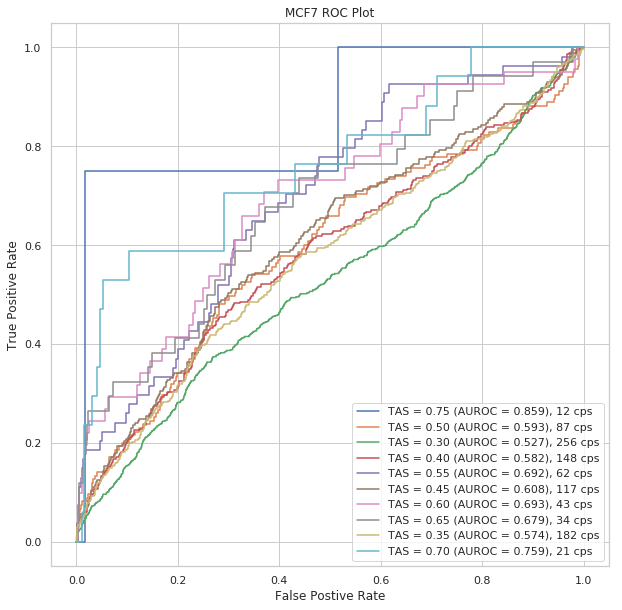

In [37]:
# set the tas thresholds you want analyzed
tas_thresholds = MCF7_spearman_corrs.keys()

# show a ROC plot comparing ROC curves for each TAS threshold
MCF7_tas2roc = roc_scores('MCF7', MCF7_spearman_corrs, tas_thresholds, MCF7_total_cps)

#### *b. A375 cell line*

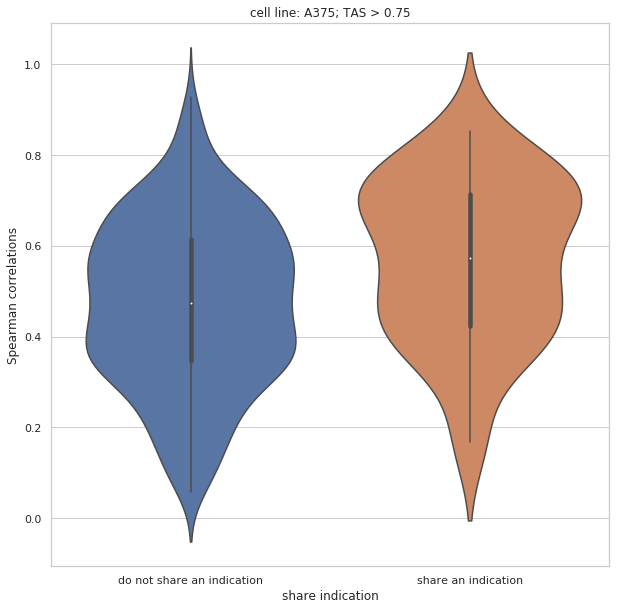

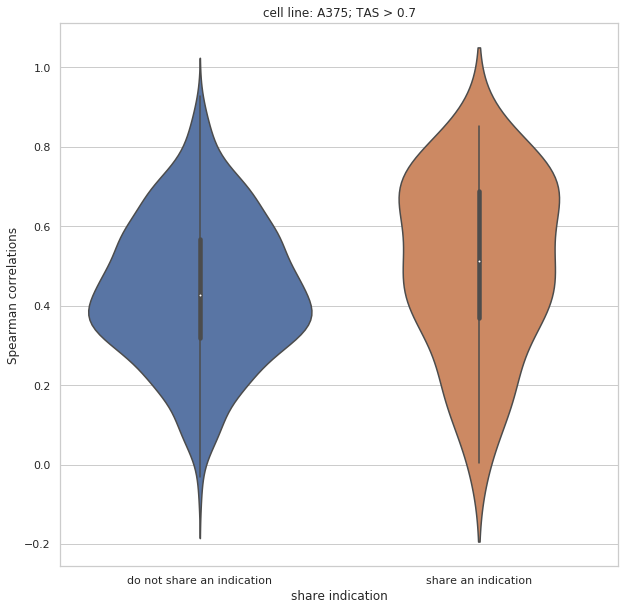

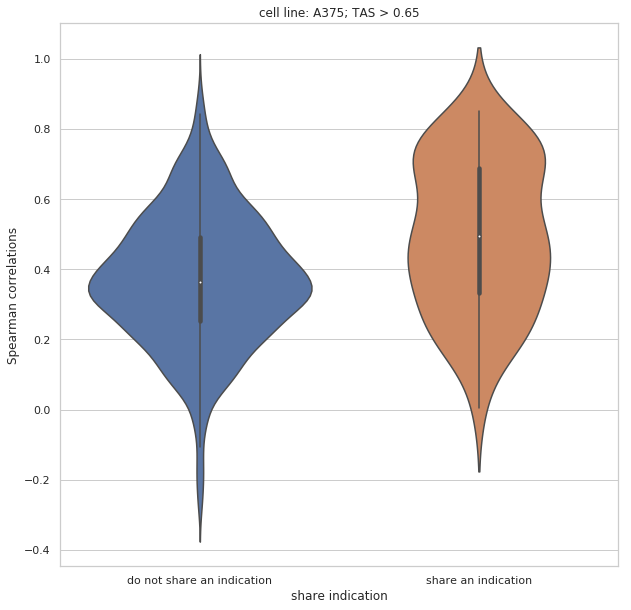

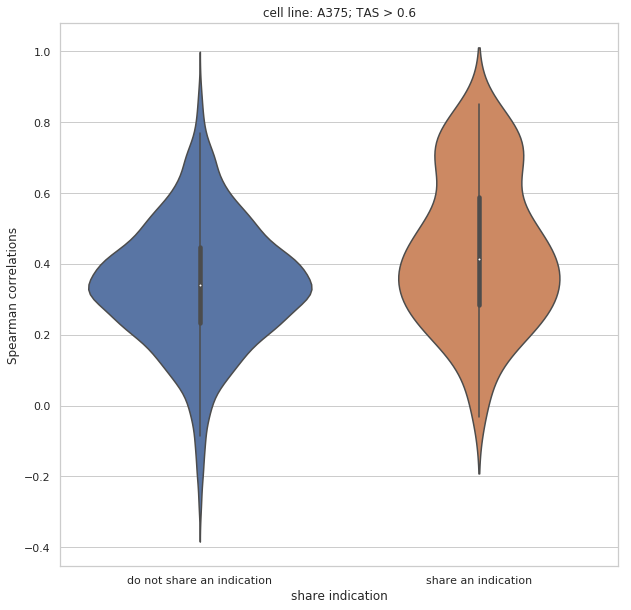

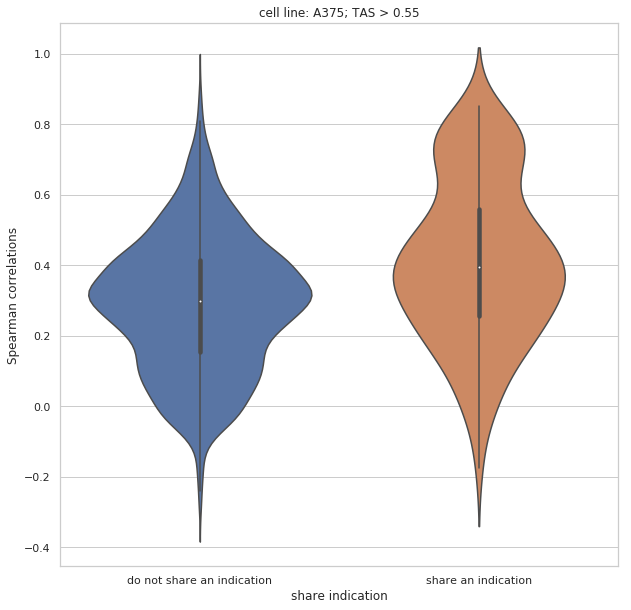

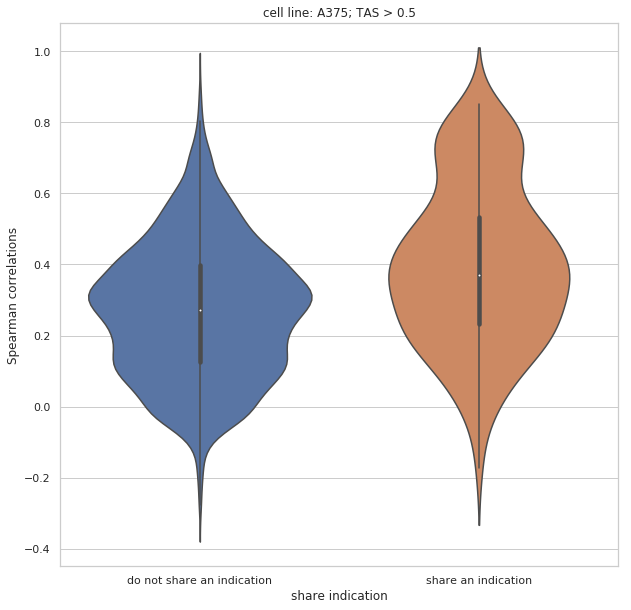

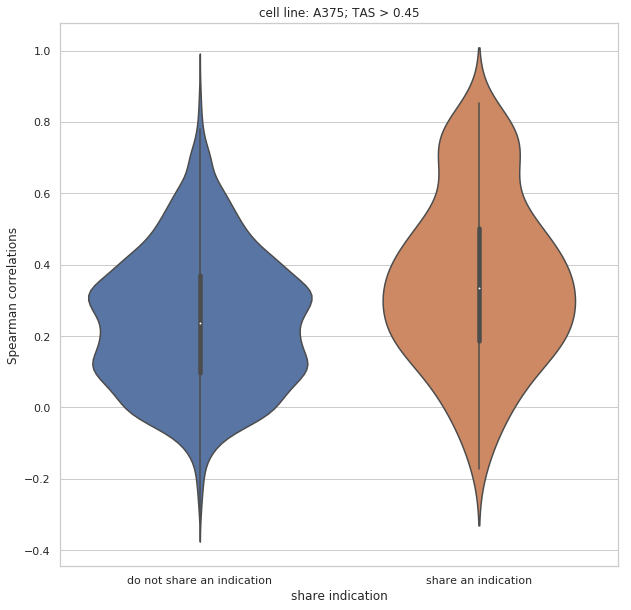

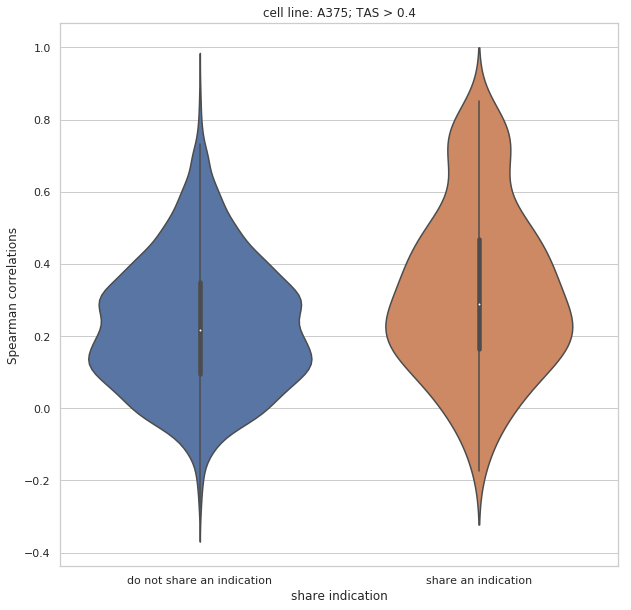

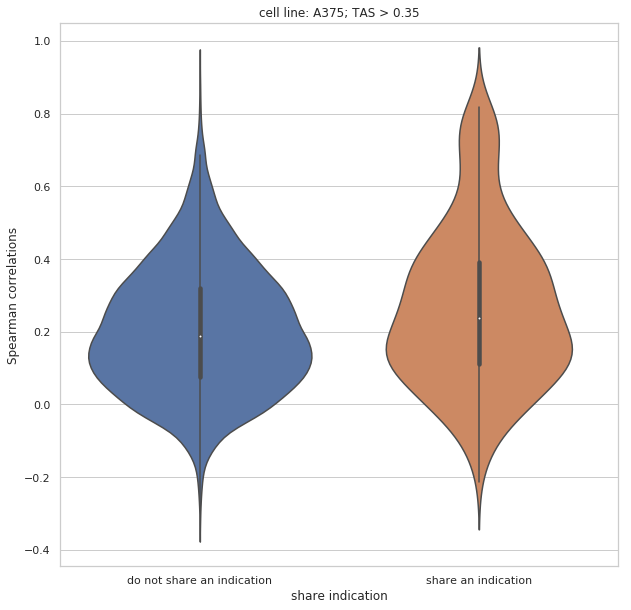

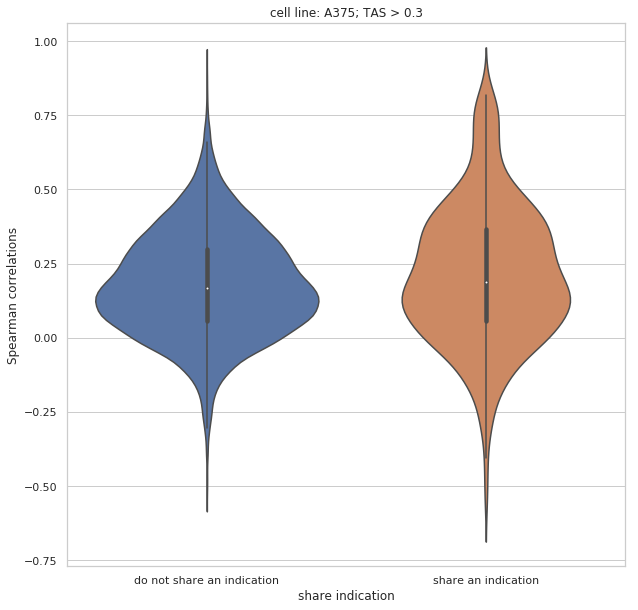

In [38]:
# create an empty dictionary to store the spearman_correlations for each the tas_threshold
A375_spearman_corrs = {}

# create a list of all TAS thresholds you want to be compared
tas_thresholds = [0.75, 0.7, 0.65, 0.6, 0.55, 0.5, 0.45, 0.4, 0.35, 0.3]

# create an empty list to store the total number of unique compounds being compared for each tas_threshold
A375_total_cps = {}

# for each TAS threshold,
for tas in tas_thresholds:
    ### 1. select the samples for that cell line above that TAS threshold
    samples2compare = select_samples('A375', tas)
    ###
    
    ### 2. map these samples to their indications
    drug2indications = drug_to_indication(samples2compare)
    
    # record the total number of unique compounds being compared
    A375_total_cps[tas] = len(drug2indications)
    ### 
    
    ### 3. select the gene signature
    # read the LINCS Level 5 dataset
    file_path = "/home/katie_huang_student_uml_edu/LINCS_dataset/LINCS_dataset.gctx"

    # select only the landmark gene of drug compounds of interest
    gene_sigs = parse(file_path, rid=lm_gene_id, cid=drug2indications.index)
    
    # create a new GCTOO object with all the metadata for pair 
    sig_info = GCToo.GCToo(data_df=gene_sigs.data_df.copy(), 
                        row_metadata_df=gene_sigs.row_metadata_df.copy(), 
                        col_metadata_df=drug2indications,
                        make_multiindex=True)
    sig_info.multi_index_df[:5]
    ###
    
    ### 4. perform a pairwise spearman correlation
    spearman_corrs = spearman_corr(sig_info, drug2indications)
    
    # add results to running list 
    A375_spearman_corrs[tas] = spearman_corrs
    ###
    
    ### 5. make violin plots for each tas threshold
    summarize_corrs('A375', tas, spearman_corrs)
    ###

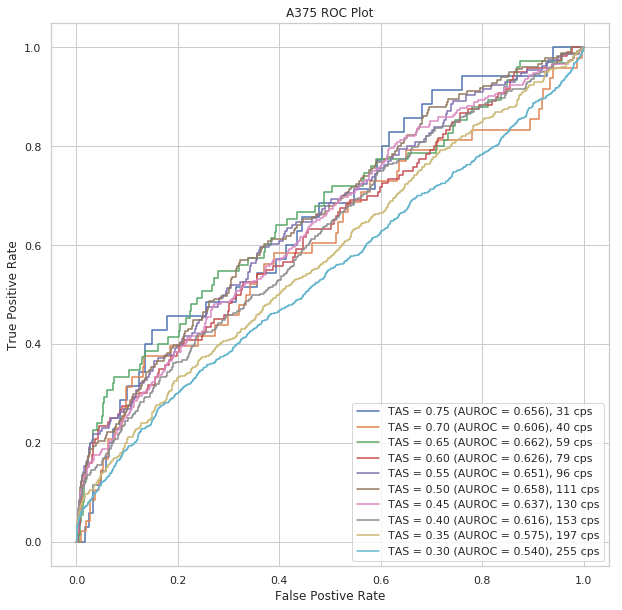

In [45]:
# show a ROC plot comparing ROC curves for each TAS threshold
A375_tas2roc = roc_scores('A375', A375_spearman_corrs, tas_thresholds, A375_total_cps)

#### *c. PC3 cell line*

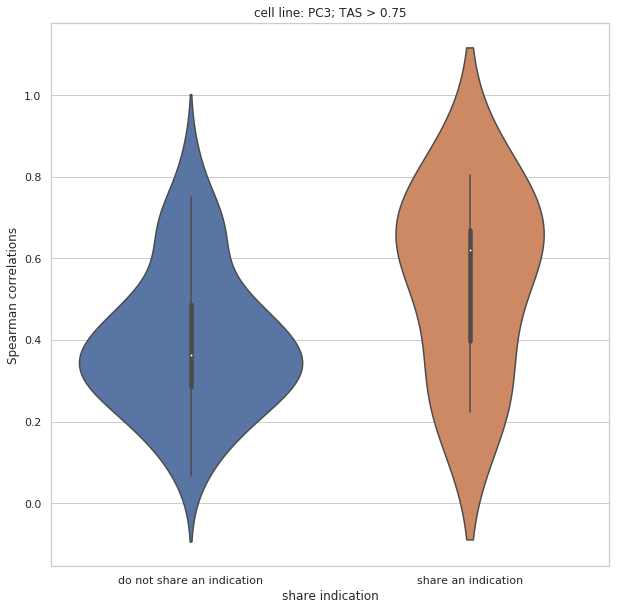

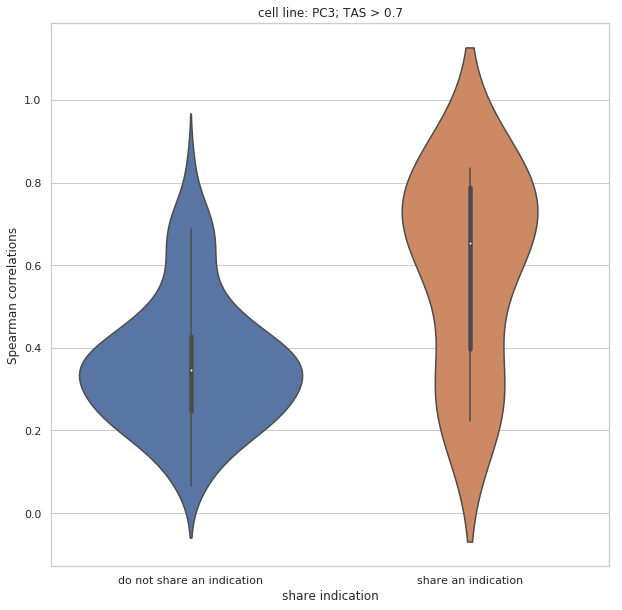

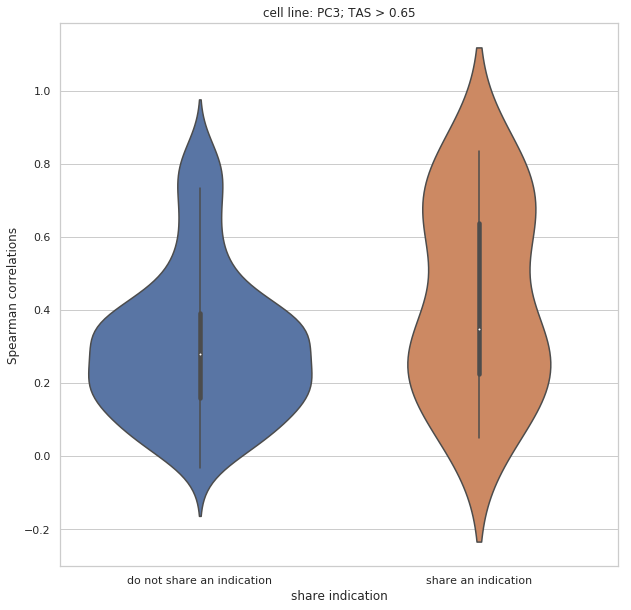

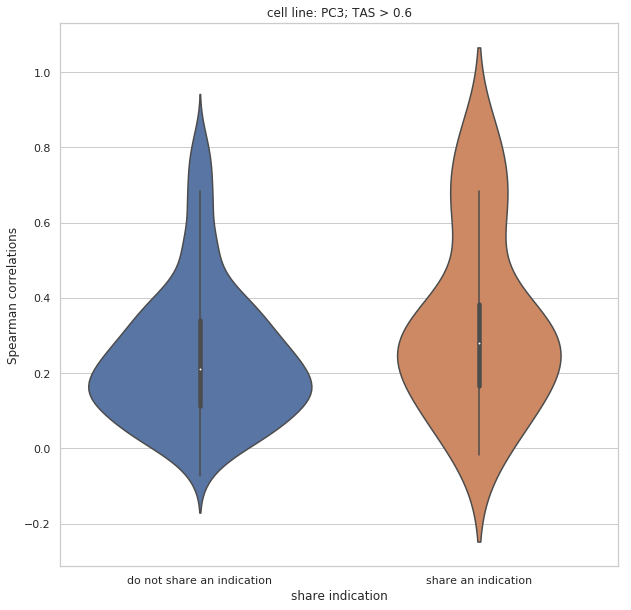

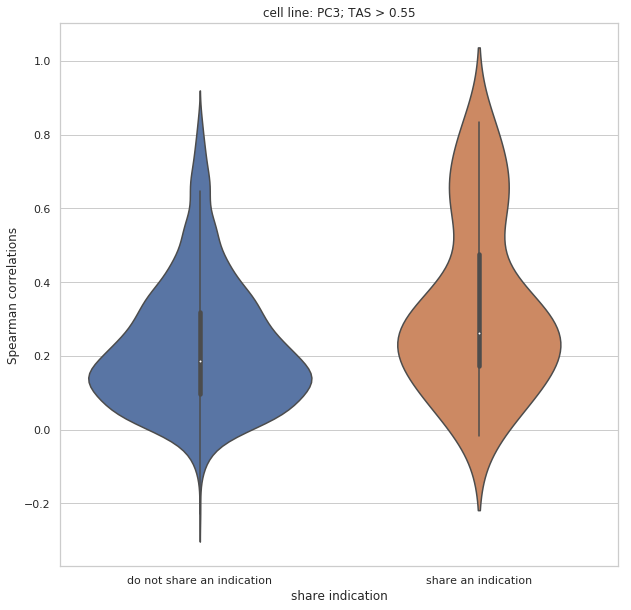

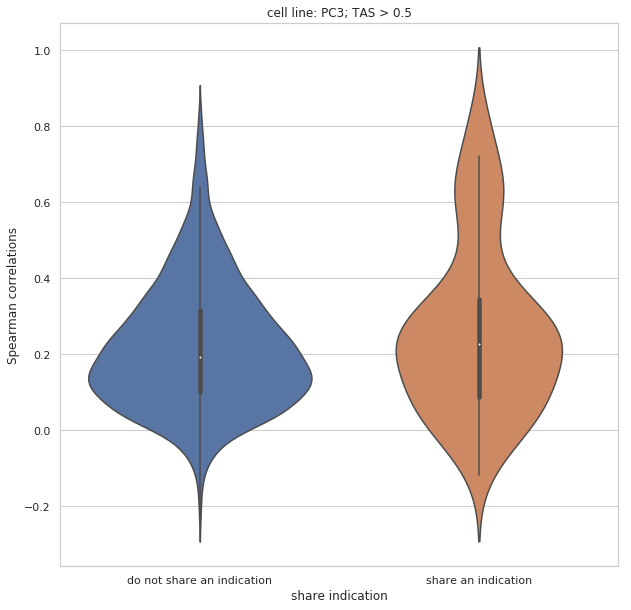

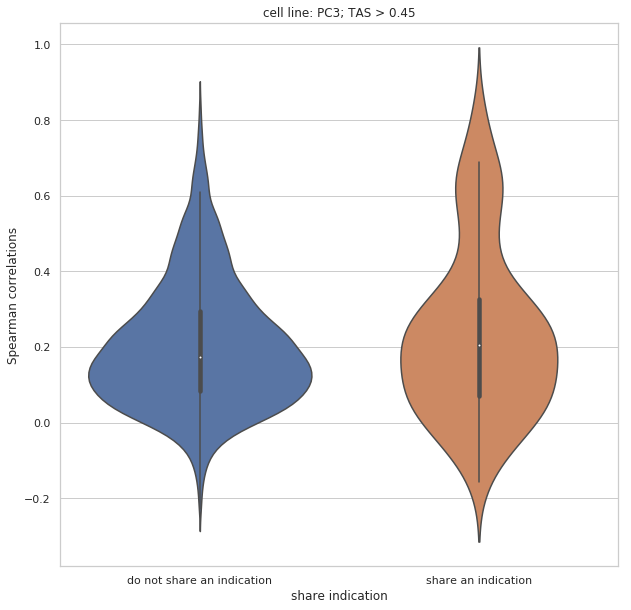

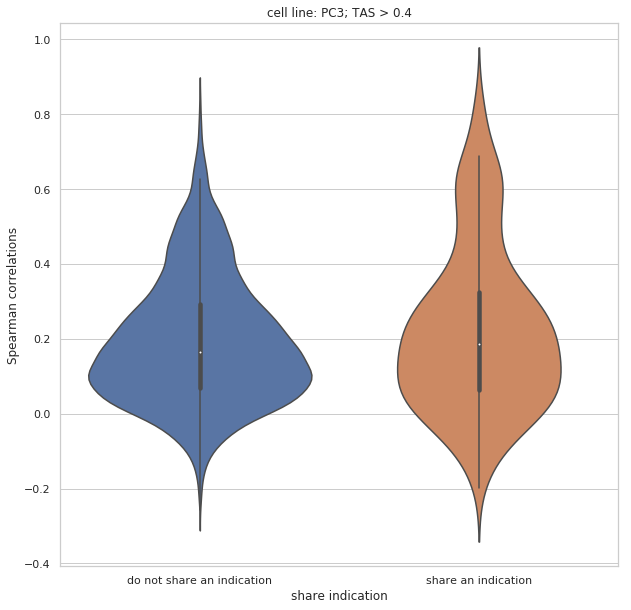

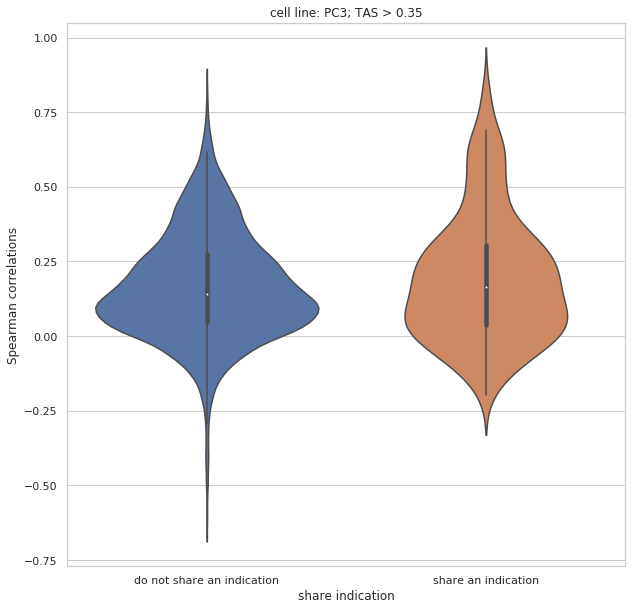

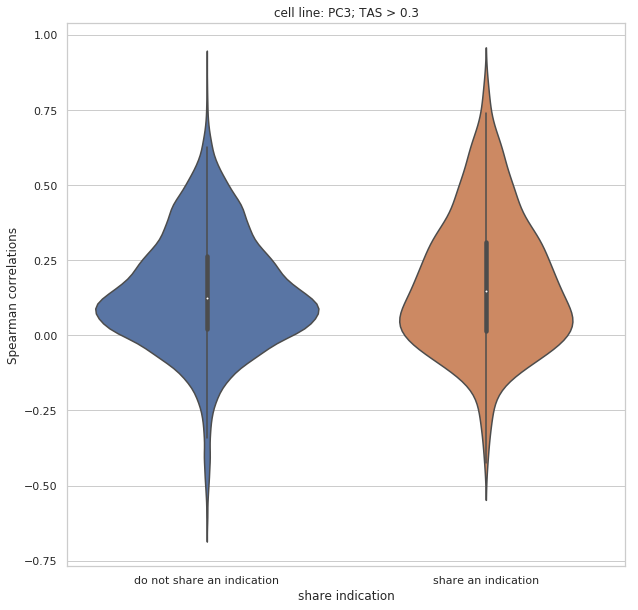

In [40]:
# create an empty dictionary to store the spearman_correlations for each the tas_threshold
PC3_spearman_corrs = {}

# create a list of all TAS thresholds you want to be compared
tas_thresholds = [0.75, 0.7, 0.65, 0.6, 0.55, 0.5, 0.45, 0.4, 0.35, 0.3]

# create an empty list to store the total number of unique compounds being compared for each tas_threshold
PC3_total_cps = {}

# for each TAS threshold,
for tas in tas_thresholds:
    ### 1. select the samples for that cell line above that TAS threshold
    samples2compare = select_samples('PC3', tas)
    ###
    
    ### 2. map these samples to their indications
    drug2indications = drug_to_indication(samples2compare)
    
    # record the total number of unique compounds being compared
    PC3_total_cps[tas] = len(drug2indications)
    ### 
    
    ### 3. select the gene signature
    # read the LINCS Level 5 dataset
    file_path = "/home/katie_huang_student_uml_edu/LINCS_dataset/LINCS_dataset.gctx"

    # select only the landmark gene of drug compounds of interest
    gene_sigs = parse(file_path, rid=lm_gene_id, cid=drug2indications.index)
    
    # create a new GCTOO object with all the metadata for pair 
    sig_info = GCToo.GCToo(data_df=gene_sigs.data_df.copy(), 
                        row_metadata_df=gene_sigs.row_metadata_df.copy(), 
                        col_metadata_df=drug2indications,
                        make_multiindex=True)
    sig_info.multi_index_df[:5]
    ###
    
    ### 4. perform a pairwise spearman correlation
    spearman_corrs = spearman_corr(sig_info, drug2indications)
    
    # add results to running list 
    PC3_spearman_corrs[tas] = spearman_corrs
    ###
    
    ### 5. make violin plots for each tas threshold
    summarize_corrs('PC3', tas, spearman_corrs)
    ###

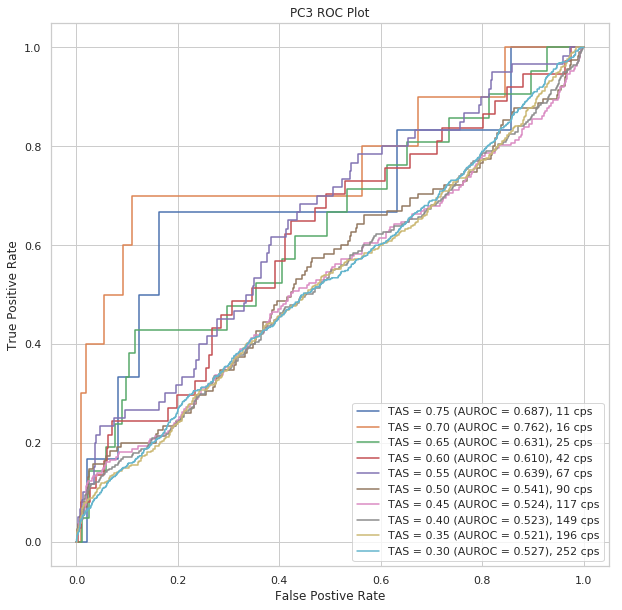

In [46]:
# show a ROC plot comparing ROC curves for each TAS threshold
PC3_tas2roc = roc_scores('PC3', PC3_spearman_corrs, tas_thresholds, PC3_total_cps)

## Compare pairs of similar drugs across all cell lines

In [42]:
# initialize an empty dictionary with top spearman correlations for similar drugs
top_corrs = {}

# go through each set of spearman correlations for each tas threshold compared
for tas in tas_thresholds:
    # get the data for each cell line
    MCF7_data = MCF7_spearman_corrs[tas]
    A375_data = A375_spearman_corrs[tas]
    PC3_data = PC3_spearman_corrs[tas]
    
    # store sorting order
    sort_order = ['share indication', 'spearman correlation']
    
    # and sort the spearman correlations from greatest to smallest, 
    # first by similar/different drugs and then spearman correlation
    MCF7_data.sort_values(by=sort_order, ascending=False, inplace=True)
    A375_data.sort_values(by=sort_order, ascending=False, inplace=True)
    PC3_data.sort_values(by=sort_order, ascending=False, inplace=True)
    
    # group each of the datasets by indication
    # then get the max spearman correlation for each
    # sort the spearman correlations from highest to lowest
    # move indications out so it is a dataframe
    # rename the columns with cell line name
    MCF7_top_corrs = MCF7_data[MCF7_data['share indication']].groupby('indication')['spearman correlation'].max()
    MCF7_top_corrs.sort_values(ascending=False, inplace=True)
    MCF7_top_corrs = MCF7_top_corrs.reset_index()
    MCF7_top_corrs.columns = ['MCF7 indication', 'MCF7 spearman correlation']
    
    
    A375_top_corrs = A375_data[A375_data['share indication']].groupby('indication')['spearman correlation'].max()
    A375_top_corrs.sort_values(ascending=False, inplace=True)
    A375_top_corrs = A375_top_corrs.reset_index()
    A375_top_corrs.columns = ['A375 indication', 'A375 spearman correlation']
    
    PC3_top_corrs = PC3_data[PC3_data['share indication']].groupby('indication')['spearman correlation'].max()
    PC3_top_corrs.sort_values(ascending=False, inplace=True)
    PC3_top_corrs = PC3_top_corrs.reset_index()
    PC3_top_corrs.columns = ['PC3 indication', 'PC3 spearman correlation']
    
    # combine all three into one dataframe
    top_corrs[tas] = pd.concat([MCF7_top_corrs, A375_top_corrs, PC3_top_corrs], axis=1)

# get the ordered dataframe for TAS>0.6
top_corrs[0.6]

,MCF7 indication,MCF7 spearman correlation,A375 indication,A375 spearman correlation,PC3 indication,PC3 spearman correlation
0,multiple myeloma,0.889649,acute myeloid leukemia (AML),0.852037,multiple myeloma,0.834510
1,acute myeloid leukemia (AML),0.774165,melanoma,0.831086,acute myeloid leukemia (AML),0.637607
2,breast cancer,0.770545,organ rejection,0.807366,acute lymphoblastic leukemia (ALL),0.572693
3,bladder cancer,0.725946,multiple myeloma,0.781509,chronic myeloid leukemia (CML),0.382509
4,"acute lymphoblastic leukemia (ALL), acute myel...",0.705075,acute lymphoblastic leukemia (ALL),0.714655,breast cancer,0.348572
5,cutaneous T-cell lymphoma (CTCL),0.586008,breast cancer,0.689633,"acute lymphoblastic leukemia (ALL), acute myel...",0.329567
6,acute lymphoblastic leukemia (ALL),0.487350,cutaneous T-cell lymphoma (CTCL),0.687908,colorectal cancer,0.312726
7,actinic keratosis (AK),0.443274,bladder cancer,0.683277,rheumatoid arthritis,0.251071
8,colorectal cancer,0.404515,"acute lymphoblastic leukemia (ALL), acute myel...",0.671483,non-small cell lung cancer (NSCLC),0.150844
9,chronic myeloid leukemia (CML),0.237446,colorectal cancer,0.647327,"chronic myeloid leukemia (CML), acute lymphobl...",0.081300


## Compare pairs of different drugs across all cell lines

In [43]:
# initialize an empty dictionary with top spearman correlations for different drugs
top_corrs = {}

# go through each set of spearman correlations for each tas threshold compared
for tas in tas_thresholds:
    # get the data for each cell line
    MCF7_data = MCF7_spearman_corrs[tas]
    A375_data = A375_spearman_corrs[tas]
    PC3_data = PC3_spearman_corrs[tas]
    
    # store sorting order
    sort_order = ['share indication', 'spearman correlation']
    
    # and sort the spearman correlations from greatest to smallest, 
    # first by similar/different drugs and then spearman correlation
    MCF7_data.sort_values(by=sort_order, ascending=False, inplace=True)
    A375_data.sort_values(by=sort_order, ascending=False, inplace=True)
    PC3_data.sort_values(by=sort_order, ascending=False, inplace=True)
    
    # store features you want to know about the pairs of different drugs
    features = ['drug1', 'drug2', 'spearman correlation']
    
    # get the max spearman correlation for pairs of different drugs
    # rename the columns with cell line name
    # reset numbering of indices
    MCF7_top_corrs = MCF7_data.loc[~MCF7_data['share indication'], features]
    MCF7_top_corrs.columns = ['MCF7 drug1', 'MCF7 drug2', 'MCF7 spearman correlation']
    MCF7_top_corrs.reset_index(drop=True, inplace=True)
    
    A375_top_corrs = A375_data.loc[~A375_data['share indication'], features]
    A375_top_corrs.columns = ['A375 drug1', 'A375 drug2', 'A375 spearman correlation']
    A375_top_corrs.reset_index(drop=True, inplace=True)
    
    PC3_top_corrs = PC3_data.loc[~PC3_data['share indication'], features]
    PC3_top_corrs.columns = ['MCF7 drug1', 'MCF7 drug2', 'MCF7 spearman correlation']
    PC3_top_corrs.reset_index(drop=True, inplace=True)
    
    # combine all three into one dataframe
    top_corrs[tas] = pd.concat([MCF7_top_corrs, A375_top_corrs, PC3_top_corrs], axis=1)
    
top_corrs[0.6].head(50)

,MCF7 drug1,MCF7 drug2,MCF7 spearman correlation,A375 drug1,A375 drug2,A375 spearman correlation,MCF7 drug1,MCF7 drug2,MCF7 spearman correlation
0,midostaurin,altrenogest,0.908978,lacidipine,metronidazole,0.928048,tioconazole,carfilzomib,0.845079
1,tioconazole,carfilzomib,0.900878,daunorubicin,SN-38,0.891780,floxuridine,ixazomib,0.844395
2,tioconazole,ixazomib-citrate,0.842353,ixazomib-citrate,metronidazole,0.886414,midostaurin,altrenogest,0.842939
3,ixazomib-citrate,metronidazole,0.818885,ixazomib-citrate,lacidipine,0.879324,ixazomib-citrate,sitagliptin,0.827849
4,penfluridol,lomitapide,0.801042,midostaurin,altrenogest,0.867231,tioconazole,ixazomib-citrate,0.823257
5,tioconazole,ixazomib,0.790062,triclosan,lomitapide,0.866060,tioconazole,ixazomib,0.816612
6,podophyllotoxin,olmesartan-medoxomil,0.785319,clofarabine,floxuridine,0.863398,lacidipine,bortezomib,0.809115
7,ixazomib-citrate,floxuridine,0.781714,atorvastatin,pitavastatin,0.860484,tioconazole,sitagliptin,0.808945
8,tioconazole,floxuridine,0.777533,tioconazole,ixazomib-citrate,0.841599,carfilzomib,lacidipine,0.796333
9,metronidazole,ixazomib,0.770292,clofarabine,cladribine,0.836042,tioconazole,floxuridine,0.786875
